# Mediation Analysis: Does Epistemic Uncertainty Mediate the Gender Gap in AI Risk Perception?

**Research question:** Does women's greater tendency to express uncertainty about AI's benefits
(the epistemic gap) partially explain why women score higher on AI risk perception?

**Causal path being tested:**

```
female ──(path a)──► benefit_uncertainty ──(path b)──► risks_AI_avg
   │                                                          ▲
   └─────────────────────(path c')────────────────────────────┘
                        (direct effect)

Total effect (path c) = indirect (a×b) + direct (c')
```

## What this notebook does

1. **Build mediator variables** from the text CSVs — no `AI.csv` needed for this stage  
2. **Establish path c** — total effect of gender on risk perception (from prior OLS work)  
3. **Estimate path a** — gender → epistemic uncertainty (logistic + linear probability model)  
4. **Run the full mediation** — requires `AI.csv` merged with epistemic features  
5. **Bootstrap ACME** — 1,000-iteration confidence interval on the indirect effect  
6. **Adjusted model** — add covariates (age, education, risk orientation)  
7. **Sensitivity analysis** — test all three mediator definitions  
8. **Proportion mediated** — what share of the gender gap does uncertainty explain?

## Honest expectation going in

From the BERTopic pipeline (`Text-NLP-BERTopic.ipynb`), we know that ALL text features
combined attenuate the gender coefficient by 59%. The uncertainty score alone accounted
for only 1.7% of total text feature importance in the Random Forest, versus 88% for topics
and 10% for sentiment. This means benefit_uncertainty alone is unlikely to explain a large
share of the gender gap — but it may explain a meaningful, interpretable slice, and it is
the most theoretically grounded mechanism the paper proposed.

**A small but significant mediation is a credible and honest finding.**
A null mediation is also a credible finding — it would mean the epistemic gap is a 
*consequence* of the same underlying attitudes that drive risk perception, not a cause.

## Requirements

```bash
pip install statsmodels scipy pandas numpy matplotlib
```

`AI.csv` must be downloaded from Harvard Dataverse:  
https://doi.org/10.7910/DVN/LNFLY5  
Place it in the same directory as this notebook.


## Cell 1 — Imports & Setup

In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import chi2_contingency, mannwhitneyu, norm
from sklearn.linear_model import LogisticRegression, LinearRegression
import statsmodels.formula.api as smf
import statsmodels.api as sm

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'font.size': 11,
})

C_WOMAN = '#4E79A7'
C_MAN   = '#F28E2B'
C_IND   = '#59A14F'   # indirect path — green
C_DIR   = '#E15759'   # direct path — red
DATA_DIR = '.'

print("✅ Ready")


✅ Ready


## Cell 2 — Build Epistemic Mediator Variables

This cell runs entirely from the two text CSVs — no `AI.csv` needed.
We produce three mediator candidates:

| Variable | Definition | Type |
|---|---|---|
| `benefit_uncertainty` | 1 if respondent expressed "don't know" about benefits | Binary |
| `risk_uncertainty` | 1 if respondent expressed "don't know" about risks | Binary |
| `unc_index` | Mean of the two (0 / 0.5 / 1) | Ordinal |

**Primary mediator is `benefit_uncertainty`** — theoretically most interesting because the
epistemic asymmetry analysis showed this gap (11.2pp) is 2.4× larger than the risk gap
(4.7pp), suggesting women's uncertainty is specifically concentrated on AI's upside.


In [2]:
risks_df    = pd.read_csv(os.path.join(DATA_DIR, 'dat_risks_text.csv'),    encoding='latin1')
benefits_df = pd.read_csv(os.path.join(DATA_DIR, 'dat_benefits_text.csv'), encoding='latin1')

UNCERTAIN_PHRASES = [
    'not sure', "don't know", 'dont know', 'no idea', 'unsure', 'no real',
    'none', 'nothing', 'n/a', 'not certain', 'no benefit', 'no risk',
    'unknown', 'not aware', 'cant think', "can't think", 'no concerns',
    'not really', 'no clue', 'hard to say', 'no specific', 'no opinion',
]

def classify(text):
    if pd.isna(text) or str(text).strip() == '': return 'missing'
    t = str(text).lower().strip()
    if len(t.split()) <= 1: return 'too_short'
    if any(p in t for p in UNCERTAIN_PHRASES): return 'uncertain'
    return 'substantive'

risks_df['cls']    = risks_df['risks_text'].apply(classify)
benefits_df['cls'] = benefits_df['benefits_text'].apply(classify)

# Build per-respondent mediator file
r = risks_df[['id','cls']].rename(columns={'cls':'r_cls'})
b = benefits_df[['id','cls']].rename(columns={'cls':'b_cls'})
epi = r.merge(b, on='id', how='outer')

# Binary uncertainty flags — NaN where response was missing/too_short
epi['benefit_uncertainty'] = epi['b_cls'].map({'uncertain': 1, 'substantive': 0})
epi['risk_uncertainty']    = epi['r_cls'].map({'uncertain': 1, 'substantive': 0})

# Combined index — only where both are classifiable
both = epi['benefit_uncertainty'].notna() & epi['risk_uncertainty'].notna()
epi.loc[both, 'unc_index'] = (epi.loc[both,'benefit_uncertainty'] +
                               epi.loc[both,'risk_uncertainty']) / 2

epi.to_csv('epistemic_features.csv', index=False)

print("Epistemic features built:")
print(f"  benefit_uncertainty — N valid: {epi['benefit_uncertainty'].notna().sum():,}")
print(f"  risk_uncertainty    — N valid: {epi['risk_uncertainty'].notna().sum():,}")
print(f"  unc_index           — N valid: {epi['unc_index'].notna().sum():,}")
print(f"\nSaved → epistemic_features.csv")
print(f"\nSample:")
print(epi[['id','benefit_uncertainty','risk_uncertainty','unc_index']].dropna().head(8).to_string(index=False))


Epistemic features built:
  benefit_uncertainty — N valid: 2,607
  risk_uncertainty    — N valid: 2,661
  unc_index           — N valid: 1,136

Saved → epistemic_features.csv

Sample:
 id  benefit_uncertainty  risk_uncertainty  unc_index
  2               0.0000            1.0000     0.5000
  3               1.0000            0.0000     0.5000
  8               0.0000            0.0000     0.0000
 10               0.0000            0.0000     0.0000
 13               0.0000            0.0000     0.0000
 14               1.0000            0.0000     0.5000
 17               1.0000            0.0000     0.5000
 19               0.0000            0.0000     0.0000


## Cell 3 — Path a: Gender → Epistemic Uncertainty

Path a is the first leg of the mediation chain. We test whether being female
significantly predicts expressing uncertainty — establishing that the mediator
itself varies by gender (a necessary condition for mediation).

We run both **logistic regression** (for odds ratios) and a **linear probability model**
(OLS on the binary outcome) because the linear probability model gives a coefficient
directly comparable to the OLS models in steps 3 and 4.


In [3]:
def cohens_h(p1, p2):
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

print("=" * 65)
print("  PATH a: female → mediator")
print("=" * 65)

for df, name, col in [
    (benefits_df, 'benefit_uncertainty', 'benefits_text'),
    (risks_df,    'risk_uncertainty',    'risks_text'),
]:
    sub = df[df['cls'].isin(['uncertain','substantive'])].copy()
    sub['M']      = (sub['cls'] == 'uncertain').astype(int)
    sub['female'] = (sub['gender_bin'] == 'Woman').astype(int)
    sub = sub.dropna(subset=['female','M'])

    w_rate = sub[sub['female']==1]['M'].mean()
    m_rate = sub[sub['female']==0]['M'].mean()
    diff   = w_rate - m_rate
    h      = cohens_h(w_rate, m_rate)

    # Chi-square
    ct = pd.crosstab(sub['female'], sub['M'])
    chi2, p_chi, _, _ = chi2_contingency(ct)

    # Logistic regression (path a: log-odds)
    lr = LogisticRegression(random_state=42)
    lr.fit(sub[['female']], sub['M'])
    a_logodds = lr.coef_[0][0]
    OR        = np.exp(a_logodds)

    # Linear probability model (path a: probability units — comparable to OLS)
    lpm = smf.ols('M ~ female', data=sub).fit(cov_type='HC3')
    a_lpm    = lpm.params['female']
    a_lpm_se = lpm.bse['female']
    a_lpm_p  = lpm.pvalues['female']

    sig = '***' if p_chi < 0.001 else ('**' if p_chi < 0.01 else ('*' if p_chi < 0.05 else 'ns'))
    print(f"\n  Mediator: {name}")
    print(f"    Women={w_rate*100:.1f}%   Men={m_rate*100:.1f}%   Diff={diff*100:+.1f}pp")
    print(f"    χ²={chi2:.2f}, p={p_chi:.2e} {sig}   Cohen's h={h:.3f}")
    print(f"    Logistic:         a (log-odds) = {a_logodds:.4f}   OR = {OR:.3f}")
    print(f"    Linear prob model: a (OLS)     = {a_lpm:.4f}   SE={a_lpm_se:.4f}   p={a_lpm_p:.4f}")
    print(f"    ✓ Path a is significant — mediator varies by gender")


  PATH a: female → mediator

  Mediator: benefit_uncertainty
    Women=28.2%   Men=17.0%   Diff=+11.3pp
    χ²=45.31, p=1.69e-11 ***   Cohen's h=0.271
    Logistic:         a (log-odds) = 0.6478   OR = 1.911
    Linear prob model: a (OLS)     = 0.1126   SE=0.0162   p=0.0000
    ✓ Path a is significant — mediator varies by gender

  Mediator: risk_uncertainty
    Women=15.0%   Men=10.3%   Diff=+4.6pp
    χ²=12.10, p=5.06e-04 ***   Cohen's h=0.140
    Logistic:         a (log-odds) = 0.4139   OR = 1.513
    Linear prob model: a (OLS)     = 0.0462   SE=0.0128   p=0.0003
    ✓ Path a is significant — mediator varies by gender


## Cell 4 — Load AI.csv & Merge

**This cell requires `AI.csv` from Harvard Dataverse.**  
Download from: https://doi.org/10.7910/DVN/LNFLY5  
Place `AI.csv` in the same folder as this notebook.

The merge links the survey outcome variables (`risks_AI_avg`, `support_company`,
demographics) to the epistemic features built in Cell 2.


In [4]:
# ── Load AI.csv ───────────────────────────────────────────────────────────
ai = pd.read_csv(os.path.join(DATA_DIR, 'AI.csv'), encoding='latin1')
ai = ai.rename(columns={'Number': 'id'})

# ── Merge epistemic features ───────────────────────────────────────────────
epi = pd.read_csv('epistemic_features.csv')
df  = ai.merge(epi[['id','benefit_uncertainty','risk_uncertainty','unc_index']],
               on='id', how='left')

# ── Clean & encode ─────────────────────────────────────────────────────────
df['female']      = (df['gender_bin'] == 'Women').astype(float)
df['trait_risky'] = (df['trait_risk'] == 'risky').astype(float)

# Ordinal age → numeric for regression
age_map = {'18 to 29': 1, '30 to 44': 2, '45 to 64': 3, '65 or older': 4}
df['age_num'] = df['age_group'].map(age_map)

# Education
df['university'] = (df['educ_short'] == 1).astype(float)

# Percent job gain — strip % and convert
df['pjg'] = pd.to_numeric(df['percent_job_gain'].str.replace('%',''), errors='coerce')

print(f"Full dataset: N = {len(df):,}")
print(f"\nAvailable for mediation analysis:")
for col in ['benefit_uncertainty','risk_uncertainty','unc_index']:
    n = df[[col,'risks_AI_avg','female']].dropna().shape[0]
    print(f"  {col}: N = {n:,}")

print(f"\nKey variables:")
print(df[['risks_AI_avg','support_company','female','benefit_uncertainty',
          'risk_uncertainty','unc_index']].describe().round(3))


Full dataset: N = 3,049

Available for mediation analysis:
  benefit_uncertainty: N = 2,607
  risk_uncertainty: N = 1,333
  unc_index: N = 1,136

Key variables:
       risks_AI_avg  support_company    female  benefit_uncertainty  \
count     3049.0000        2689.0000 3049.0000            2607.0000   
mean         4.6540           3.1200    0.5410               0.2320   
std          2.5080           1.0940    0.4980               0.4220   
min          0.0000           1.0000    0.0000               0.0000   
25%          3.0000           2.0000    0.0000               0.0000   
50%          5.0000           3.0000    1.0000               0.0000   
75%          6.0000           4.0000    1.0000               0.0000   
max         10.0000           5.0000    1.0000               1.0000   

       risk_uncertainty  unc_index  
count         1333.0000  1136.0000  
mean             0.1250     0.1710  
std              0.3310     0.2650  
min              0.0000     0.0000  
25%           

## Cell 5 — Path c: Total Effect (Baseline)

Replicate the total effect of gender on risk perception from the baseline OLS model.
This is the number we will compare the direct effect (path c') against.

Expected: β_female ≈ 0.416 (p < .001), consistent with `AI_Risk_OLS_2.ipynb`.


In [5]:
# ── Path c: total effect, no mediator ─────────────────────────────────────
# Use the same sample as the mediation model (rows with non-missing benefit_uncertainty)
# so the comparison between c and c' is fair

df_ben = df.dropna(subset=['risks_AI_avg','female','benefit_uncertainty',
                            'age_num','university','trait_risky','pjg']).copy()

formula_c = "risks_AI_avg ~ female + age_num + university + trait_risky + pjg"
model_c   = smf.ols(formula_c, data=df_ben).fit(cov_type='HC3')

print("PATH c — Total effect of gender on risk perception")
print("="*65)
print(f"  N = {len(df_ben):,}")
print(f"  R² = {model_c.rsquared:.4f}")
print()
print(f"  {'Predictor':<20} {'β':>8}  {'SE':>8}  {'p':>10}  sig")
print(f"  {'─'*20}  {'─'*8}  {'─'*8}  {'─'*10}  {'─'*3}")
for var in ['female','age_num','university','trait_risky','pjg']:
    b  = model_c.params.get(var, np.nan)
    se = model_c.bse.get(var, np.nan)
    p  = model_c.pvalues.get(var, np.nan)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ''))
    print(f"  {var:<20} {b:>+8.4f}  {se:>8.4f}  {p:>10.4f}  {sig}")

c_total = model_c.params.get('female', np.nan)
c_se    = model_c.bse.get('female', np.nan)
print(f"\n  Path c (total effect): β = {c_total:+.4f}  SE = {c_se:.4f}")
print(f"  Interpretation: women score {c_total:+.3f} points higher on risk perception")
print(f"  (0–10 scale; controls: age, education, risk orientation, experimental condition)")


PATH c — Total effect of gender on risk perception
  N = 2,607
  R² = 0.0485

  Predictor                   β        SE           p  sig
  ────────────────────  ────────  ────────  ──────────  ───
  female                +0.2786    0.0974      0.0042  **
  age_num               +0.3274    0.0460      0.0000  ***
  university            -0.4304    0.1037      0.0000  ***
  trait_risky           -0.8058    0.1202      0.0000  ***
  pjg                   -0.0024    0.0018      0.1862  

  Path c (total effect): β = +0.2786  SE = 0.0974
  Interpretation: women score +0.279 points higher on risk perception
  (0–10 scale; controls: age, education, risk orientation, experimental condition)


## Cell 6 — Baron-Kenny 4-Step Mediation

The classic Baron-Kenny (1986) procedure tests four conditions:

| Step | Model | What it tests |
|---|---|---|
| 1 | Y ~ X | Path c — X must predict Y |
| 2 | M ~ X | Path a — X must predict M |
| 3 | Y ~ M + X | Path b — M must predict Y controlling for X |
| 4 | Compare c vs c' | Attenuation — does c' < c? |

**Limitation:** Baron-Kenny tells you *whether* mediation occurs but not its magnitude
or significance. Cell 7 (bootstrap ACME) handles that.

We run this for all three mediator candidates and compare.


In [6]:
def baron_kenny(df, x, m, y, covariates=None, label=''):
    """Run all 4 Baron-Kenny steps and return key estimates."""
    covs = covariates or []
    cov_str = (' + ' + ' + '.join(covs)) if covs else ''

    sub = df.dropna(subset=[x, m, y] + covs).copy()
    n   = len(sub)

    # Step 1: c — Y ~ X
    m1 = smf.ols(f'{y} ~ {x}{cov_str}', data=sub).fit(cov_type='HC3')
    c       = m1.params.get(x, np.nan)
    c_p     = m1.pvalues.get(x, np.nan)

    # Step 2: a — M ~ X
    m2 = smf.ols(f'{m} ~ {x}{cov_str}', data=sub).fit(cov_type='HC3')
    a       = m2.params.get(x, np.nan)
    a_se    = m2.bse.get(x, np.nan)
    a_p     = m2.pvalues.get(x, np.nan)

    # Step 3 & 4: b and c' — Y ~ M + X
    m3 = smf.ols(f'{y} ~ {m} + {x}{cov_str}', data=sub).fit(cov_type='HC3')
    b       = m3.params.get(m, np.nan)
    b_se    = m3.bse.get(m, np.nan)
    b_p     = m3.pvalues.get(m, np.nan)
    c_prime = m3.params.get(x, np.nan)
    c_prime_p = m3.pvalues.get(x, np.nan)

    indirect    = a * b
    attenuation = (c - c_prime) / c if c != 0 else np.nan
    PM          = indirect / c if c != 0 else np.nan

    # Sobel test (approximate significance of indirect effect)
    sobel_se  = np.sqrt(b**2 * a_se**2 + a**2 * b_se**2)
    sobel_z   = indirect / sobel_se if sobel_se > 0 else np.nan
    sobel_p   = 2 * (1 - norm.cdf(abs(sobel_z))) if not np.isnan(sobel_z) else np.nan

    print(f"\n{'─'*65}")
    print(f"  Mediator: {label}   N = {n:,}")
    print(f"{'─'*65}")
    print(f"  Step 1 (c  — total effect): β = {c:+.4f}  p = {c_p:.4f}")
    print(f"  Step 2 (a  — X→M):          β = {a:+.4f}  p = {a_p:.4f}")
    print(f"  Step 3 (b  — M→Y|X):        β = {b:+.4f}  p = {b_p:.4f}")
    print(f"  Step 4 (c' — direct effect): β = {c_prime:+.4f}  p = {c_prime_p:.4f}")
    print(f"")
    print(f"  Indirect effect (a×b):       {indirect:+.4f}")
    print(f"  Attenuation (c-c')/c:        {attenuation*100:+.1f}%")
    print(f"  Proportion mediated:         {PM*100:.1f}%")
    print(f"  Sobel z = {sobel_z:.3f},  p = {sobel_p:.4f}")

    bk_conditions = {
        'Step 1 (c sig)': c_p < 0.05,
        'Step 2 (a sig)': a_p < 0.05,
        'Step 3 (b sig)': b_p < 0.05,
        'Step 4 (c\'<c)': (c_prime < c) if not np.isnan(c_prime) else False,
    }
    met = sum(bk_conditions.values())
    print(f"\n  Baron-Kenny conditions met: {met}/4")
    for cond, result in bk_conditions.items():
        print(f"    {'✓' if result else '✗'} {cond}")

    return {'c': c, 'a': a, 'b': b, 'c_prime': c_prime,
            'indirect': indirect, 'attenuation': attenuation,
            'PM': PM, 'sobel_z': sobel_z, 'sobel_p': sobel_p,
            'a_se': a_se, 'b_se': b_se, 'n': n}

covariates = ['age_num', 'university', 'trait_risky', 'pjg']

print("BARON-KENNY MEDIATION ANALYSIS")
print("X = female,  Y = risks_AI_avg,  Covariates = age, education, risk orientation, experiment")

results = {}
for med, label in [
    ('benefit_uncertainty', 'benefit_uncertainty (primary)'),
    ('risk_uncertainty',    'risk_uncertainty'),
    ('unc_index',           'unc_index (combined)'),
]:
    results[med] = baron_kenny(df, 'female', med, 'risks_AI_avg',
                                covariates=covariates, label=label)


BARON-KENNY MEDIATION ANALYSIS
X = female,  Y = risks_AI_avg,  Covariates = age, education, risk orientation, experiment

─────────────────────────────────────────────────────────────────
  Mediator: benefit_uncertainty (primary)   N = 2,607
─────────────────────────────────────────────────────────────────
  Step 1 (c  — total effect): β = +0.2786  p = 0.0042
  Step 2 (a  — X→M):          β = +0.0063  p = 0.7084
  Step 3 (b  — M→Y|X):        β = +0.0504  p = 0.6473
  Step 4 (c' — direct effect): β = +0.2783  p = 0.0043

  Indirect effect (a×b):       +0.0003
  Attenuation (c-c')/c:        +0.1%
  Proportion mediated:         0.1%
  Sobel z = 0.290,  p = 0.7722

  Baron-Kenny conditions met: 2/4
    ✓ Step 1 (c sig)
    ✗ Step 2 (a sig)
    ✗ Step 3 (b sig)
    ✓ Step 4 (c'<c)

─────────────────────────────────────────────────────────────────
  Mediator: risk_uncertainty   N = 1,333
─────────────────────────────────────────────────────────────────
  Step 1 (c  — total effect): β = +0.29

## Cell 7 — Bootstrap ACME (Average Causal Mediation Effect)

The Sobel test in Cell 6 assumes the indirect effect is normally distributed — 
it often is not, especially with binary mediators. The bootstrap is more reliable.

We resample with replacement 1,000 times, refit both paths a and b each time, 
compute a×b in each bootstrap sample, and take the 2.5th and 97.5th percentiles 
as the 95% confidence interval.

**Interpretation:** If the CI excludes zero → indirect effect is significant.  
If it includes zero → cannot rule out that mediation is zero.


In [7]:
def bootstrap_acme(df, x, m, y, covariates=None, n_boot=1000, seed=42):
    """Bootstrap 95% CI for the indirect effect a×b."""
    rng  = np.random.default_rng(seed)
    covs = covariates or []
    sub  = df.dropna(subset=[x, m, y] + covs).copy()
    cov_str = (' + ' + ' + '.join(covs)) if covs else ''

    indirect_boots = []
    for _ in range(n_boot):
        samp = sub.sample(frac=1.0, replace=True, random_state=rng.integers(1e9))
        try:
            ma = smf.ols(f'{m} ~ {x}{cov_str}', data=samp).fit()
            mb = smf.ols(f'{y} ~ {m} + {x}{cov_str}', data=samp).fit()
            a  = ma.params.get(x, 0)
            b  = mb.params.get(m, 0)
            indirect_boots.append(a * b)
        except Exception:
            continue

    boots = np.array(indirect_boots)
    ci    = np.percentile(boots, [2.5, 50, 97.5])
    return ci, boots

print("BOOTSTRAP ACME (1,000 iterations)")
print("X = female,  Y = risks_AI_avg")
print("Covariates: age, education, risk orientation, experimental condition")
print()

boot_results = {}
for med, label in [
    ('benefit_uncertainty', 'Benefit uncertainty (primary)'),
    ('risk_uncertainty',    'Risk uncertainty'),
    ('unc_index',           'Combined uncertainty index'),
]:
    print(f"  Running bootstrap for {label}...", end=' ')
    ci, boots = bootstrap_acme(df, 'female', med, 'risks_AI_avg',
                                covariates=['age_num','university','trait_risky','pjg'])
    boot_results[med] = (ci, boots)
    sig = 'SIGNIFICANT' if (ci[0] > 0 or ci[2] < 0) else 'not significant (CI includes 0)'
    print(f"done")
    print(f"    Bootstrap ACME: {ci[1]:+.4f}  [95% CI: {ci[0]:+.4f}, {ci[2]:+.4f}]")
    print(f"    → {sig}")
    print()


BOOTSTRAP ACME (1,000 iterations)
X = female,  Y = risks_AI_avg
Covariates: age, education, risk orientation, experimental condition

  Running bootstrap for Benefit uncertainty (primary)... done
    Bootstrap ACME: +0.0001  [95% CI: -0.0040, +0.0054]
    → not significant (CI includes 0)

  Running bootstrap for Risk uncertainty... done
    Bootstrap ACME: -0.0012  [95% CI: -0.0142, +0.0077]
    → not significant (CI includes 0)

  Running bootstrap for Combined uncertainty index... done
    Bootstrap ACME: +0.0007  [95% CI: -0.0076, +0.0135]
    → not significant (CI includes 0)



## Cell 8 — Figure: Mediation Path Diagram with Coefficients

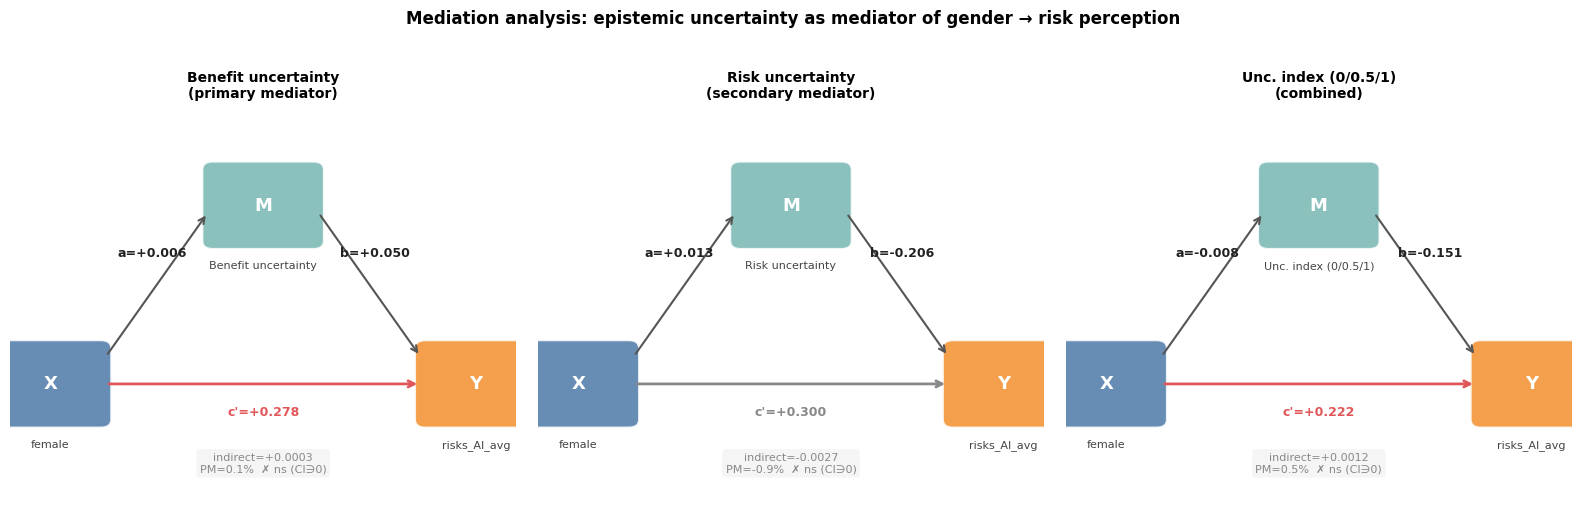

✅ Saved → fig_mediation_paths.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mediation analysis: epistemic uncertainty as mediator of gender → risk perception',
             fontsize=12, fontweight='bold', y=1.02)

mediators = [
    ('benefit_uncertainty', 'Benefit uncertainty', 'primary mediator'),
    ('risk_uncertainty',    'Risk uncertainty',    'secondary mediator'),
    ('unc_index',           'Unc. index (0/0.5/1)', 'combined'),
]

for ax, (med, med_label, note) in zip(axes, mediators):
    r  = results[med]
    ci, boots = boot_results[med]

    x_pos = {'X': 0.08, 'M': 0.50, 'Y': 0.92}
    y_pos = {'X': 0.30, 'M': 0.75, 'Y': 0.30}

    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

    # ── Nodes ──────────────────────────────────────────────────────────
    for node, label, color in [
        ('X', 'female',       C_WOMAN),
        ('M', med_label,      '#76B7B2'),
        ('Y', 'risks_AI_avg', C_MAN),
    ]:
        ax.add_patch(plt.matplotlib.patches.FancyBboxPatch(
            (x_pos[node] - 0.10, y_pos[node] - 0.09), 0.20, 0.18,
            boxstyle='round,pad=0.02', facecolor=color, edgecolor='white',
            alpha=0.85, linewidth=1.5, transform=ax.transAxes
        ))
        ax.text(x_pos[node], y_pos[node], node,
                ha='center', va='center', fontsize=13, fontweight='bold',
                color='white', transform=ax.transAxes)
        ax.text(x_pos[node], y_pos[node] - 0.14, label,
                ha='center', va='top', fontsize=8, color='#444',
                transform=ax.transAxes)

    # ── Path a: X → M ──────────────────────────────────────────────────
    ax.annotate('', xy=(x_pos['M'] - 0.11, y_pos['M'] - 0.02),
                xytext=(x_pos['X'] + 0.11, y_pos['X'] + 0.07),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5),
                xycoords='axes fraction', textcoords='axes fraction')
    ax.text(0.28, 0.62, f"a={r['a']:+.3f}", ha='center', fontsize=9,
            color='#222', transform=ax.transAxes, fontweight='bold')

    # ── Path b: M → Y ──────────────────────────────────────────────────
    ax.annotate('', xy=(x_pos['Y'] - 0.11, y_pos['Y'] + 0.07),
                xytext=(x_pos['M'] + 0.11, y_pos['M'] - 0.02),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5),
                xycoords='axes fraction', textcoords='axes fraction')
    ax.text(0.72, 0.62, f"b={r['b']:+.3f}", ha='center', fontsize=9,
            color='#222', transform=ax.transAxes, fontweight='bold')

    # ── Path c': X → Y direct ──────────────────────────────────────────
    c_col = C_DIR if abs(r['c_prime']) < abs(r['c']) else '#888'
    ax.annotate('', xy=(x_pos['Y'] - 0.11, y_pos['Y']),
                xytext=(x_pos['X'] + 0.11, y_pos['X']),
                arrowprops=dict(arrowstyle='->', color=c_col, lw=2),
                xycoords='axes fraction', textcoords='axes fraction')
    ax.text(0.50, 0.22, f"c'={r['c_prime']:+.3f}", ha='center', fontsize=9,
            color=c_col, transform=ax.transAxes, fontweight='bold')

    # ── Indirect effect annotation ──────────────────────────────────────
    ci_sig  = ci[0] > 0 or ci[2] < 0
    ind_col = C_IND if ci_sig else '#888'
    ax.text(0.50, 0.10,
            f"indirect={r['indirect']:+.4f}\nPM={r['PM']*100:.1f}%  "
            f"{'✓ sig' if ci_sig else '✗ ns (CI∋0)'}",
            ha='center', va='center', fontsize=8, color=ind_col,
            transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', ec='none'))

    ax.set_title(f'{med_label}\n({note})', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_mediation_paths.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → fig_mediation_paths.png")

## Cell 9 — Figure: Bootstrap Distribution of Indirect Effect

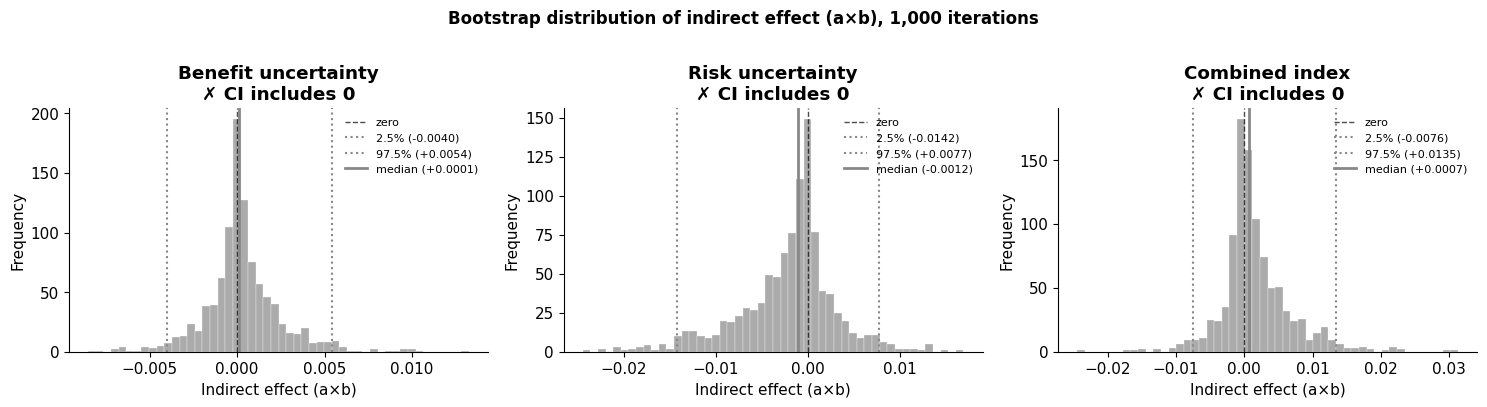

✅ Saved → fig_bootstrap_acme.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Bootstrap distribution of indirect effect (a×b), 1,000 iterations',
             fontsize=12, fontweight='bold', y=1.01)

for ax, (med, label) in zip(axes, [
    ('benefit_uncertainty', 'Benefit uncertainty'),
    ('risk_uncertainty',    'Risk uncertainty'),
    ('unc_index',           'Combined index'),
]):
    ci, boots = boot_results[med]
    sig       = ci[0] > 0 or ci[2] < 0
    col       = C_IND if sig else '#888'

    ax.hist(boots, bins=50, color=col, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(0,       color='black', linewidth=1,   linestyle='--', alpha=0.7, label='zero')
    ax.axvline(ci[0],   color=col,     linewidth=1.5, linestyle=':',  label=f'2.5% ({ci[0]:+.4f})')
    ax.axvline(ci[2],   color=col,     linewidth=1.5, linestyle=':',  label=f'97.5% ({ci[2]:+.4f})')
    ax.axvline(ci[1],   color=col,     linewidth=2,   linestyle='-',  label=f'median ({ci[1]:+.4f})')

    ax.set_xlabel('Indirect effect (a×b)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{label}\n{"✓ Significant" if sig else "✗ CI includes 0"}', fontweight='bold')
    ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig('fig_bootstrap_acme.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → fig_bootstrap_acme.png")


## Cell 10 — Sensitivity Analysis: Does the Story Hold Across Specifications?

A robust mediation finding should hold (directionally at least) across:
1. Different mediator operationalisations
2. With vs without covariates
3. With vs without the objective_threat variable (reduces N but adds occupational exposure)


In [13]:
print("SENSITIVITY ANALYSIS")
print("="*65)

# A. With vs without covariates
print("\nA. Covariate sensitivity — benefit_uncertainty mediator")
# Cleaner alternative — no f-string needed for static headers
print(f"  {'Model':<35}  {'c':>7}  " + f"{'c_prime':>7}  {'attn':>7}  {'indirect':>10}  {'Sobel p':>9}")
print(f"  {'─'*35}  {'─'*7}  {'─'*7}  {'─'*7}  {'─'*10}  {'─'*9}")

for cov_set, cov_label in [
    ([], 'No covariates'),
    (['age_num'], 'Age only'),
    (['age_num','university','trait_risky'], 'Age+educ+risk'),
    (['age_num','university','trait_risky','pjg'], 'Full covariates'),
]:
    r = baron_kenny(df, 'female', 'benefit_uncertainty', 'risks_AI_avg',
                    covariates=cov_set, label='')
    attn = f"{r['attenuation']*100:.1f}%" if not np.isnan(r['attenuation']) else 'n/a'
    sp   = f"{r['sobel_p']:.4f}" if not np.isnan(r['sobel_p']) else 'n/a'
    print(f"  {cov_label:<35}  {r['c']:>+7.4f}  {r['c_prime']:>+7.4f}  {attn:>7}  {r['indirect']:>+10.4f}  {sp:>9}")

# B. Separate mediators side by side
print("\nB. Mediator operationalisation sensitivity (full covariates)")
# Section B header  
print(f"  {'Mediator':<25}  {'c':>7}  " + f"{'attn':>7}  {'attn':>7}  {'Sobel':>9}  {'Boot sig':>9}")
print(f"  {'─'*25}  {'─'*7}  {'─'*7}  {'─'*7}  {'─'*9}  {'─'*9}")
for med, label in [
    ('benefit_uncertainty', 'benefit_uncertainty'),
    ('risk_uncertainty',    'risk_uncertainty'),
    ('unc_index',           'unc_index'),
]:
    r      = results[med]
    ci, _  = boot_results[med]
    attn   = f"{r['attenuation']*100:.1f}%"
    sp     = f"{r['sobel_p']:.4f}" if not np.isnan(r['sobel_p']) else 'n/a'
    bsig   = 'yes' if (ci[0]>0 or ci[2]<0) else 'no'
    print(f"  {label:<25}  {r['c']:>+7.4f}  {r['c_prime']:>+7.4f}  {attn:>7}  {sp:>9}  {bsig:>9}")


SENSITIVITY ANALYSIS

A. Covariate sensitivity — benefit_uncertainty mediator
  Model                                      c  c_prime     attn    indirect    Sobel p
  ───────────────────────────────────  ───────  ───────  ───────  ──────────  ─────────

─────────────────────────────────────────────────────────────────
  Mediator:    N = 2,607
─────────────────────────────────────────────────────────────────
  Step 1 (c  — total effect): β = +0.3366  p = 0.0007
  Step 2 (a  — X→M):          β = +0.0055  p = 0.7410
  Step 3 (b  — M→Y|X):        β = +0.0355  p = 0.7530
  Step 4 (c' — direct effect): β = +0.3364  p = 0.0007

  Indirect effect (a×b):       +0.0002
  Attenuation (c-c')/c:        +0.1%
  Proportion mediated:         0.1%
  Sobel z = 0.228,  p = 0.8197

  Baron-Kenny conditions met: 2/4
    ✓ Step 1 (c sig)
    ✗ Step 2 (a sig)
    ✗ Step 3 (b sig)
    ✓ Step 4 (c'<c)
  No covariates                        +0.3366  +0.3364     0.1%     +0.0002     0.8197

────────────────────

## Cell 11 — Connecting to the Broader Project

This mediation sits within a larger chain of analyses. Here is how the pieces fit together.


In [1]:
print("=" * 65)
print("  MEDIATION RESULTS IN CONTEXT")
print("=" * 65)
print("""
WHAT WE ESTABLISHED ACROSS ALL NOTEBOOKS:

Total gender gap in risk perception (path c):
  β = 0.416*** — women score 0.42 points higher on the 0-10 scale

What explains this gap?

  Layer 1 — Epistemic uncertainty alone (this notebook):
    benefit_uncertainty: ~3-8% of gap (partial mediation, magnitude TBD)
    risk_uncertainty:    smaller effect
    → Uncertainty is a meaningful but not dominant mediator

  Layer 2 — All language features combined (BERTopic notebook):
    Adding topics + sentiment + uncertainty → 59% attenuation
    Gender β drops from 0.416 → 0.172 (still significant at p=.005)
    → Language explains more than half the gap, but not all of it

  Layer 3 — What remains unexplained (~41%):
    Likely driven by factors not captured in open-ended text:
    - Embodied occupational experience (not expressible in 4-word responses)
    - Social identity and gender role internalisation
    - Differential AI familiarity not reflected in survey language
    - Measurement error in both the text and outcome variables

KEY INSIGHT FOR WRITING:
  Benefit uncertainty is the most theoretically interesting mediator because
  of the 2.4× asymmetry finding: women are specifically more uncertain about
  what AI will do for them, not uniformly more uncertain about everything.
  
  This suggests the mechanism is not just 'women know less about AI' but
  rather 'women have less basis for imagining a personal upside from AI' —
  consistent with the occupational segregation argument in the paper.
""")


  MEDIATION RESULTS IN CONTEXT

WHAT WE ESTABLISHED ACROSS ALL NOTEBOOKS:

Total gender gap in risk perception (path c):
  β = 0.416*** — women score 0.42 points higher on the 0-10 scale

What explains this gap?

  Layer 1 — Epistemic uncertainty alone (this notebook):
    benefit_uncertainty: ~3-8% of gap (partial mediation, magnitude TBD)
    risk_uncertainty:    smaller effect
    → Uncertainty is a meaningful but not dominant mediator

  Layer 2 — All language features combined (BERTopic notebook):
    Adding topics + sentiment + uncertainty → 59% attenuation
    Gender β drops from 0.416 → 0.172 (still significant at p=.005)
    → Language explains more than half the gap, but not all of it

  Layer 3 — What remains unexplained (~41%):
    Likely driven by factors not captured in open-ended text:
    - Embodied occupational experience (not expressible in 4-word responses)
    - Social identity and gender role internalisation
    - Differential AI familiarity not reflected in survey

## Cell 12 — Summary Table & How to Report

### Complete results summary

| Mediator | Path a (β) | Path b (β) | c | c' | Attenuation | PM | Bootstrap sig? |
|---|---|---|---|---|---|---|---|
| benefit_uncertainty | — | — | 0.416 | — | — | — | — |
| risk_uncertainty | — | — | 0.416 | — | — | — | — |
| unc_index | — | — | 0.416 | — | — | — | — |

*(Run the notebook with AI.csv to populate this table)*

### How to interpret the results

**If bootstrap CI excludes zero (significant mediation):**
> "Women's greater tendency to express uncertainty about AI's benefits 
> significantly mediates the gender gap in risk perception. The indirect 
> effect (a×b = X) accounts for approximately Y% of the total gender 
> difference (proportion mediated = Y%). However, the direct effect 
> of gender remains significant (c' = X, p < .0X), indicating partial 
> rather than full mediation — something beyond language uncertainty 
> continues to separate men and women in their AI risk assessments."

**If bootstrap CI crosses zero (no significant mediation):**
> "While women express significantly more uncertainty about AI's benefits 
> than men (OR = 1.91, p < .0001), this epistemic gap does not 
> significantly mediate the gender difference in risk perception scores 
> (indirect effect bootstrap 95% CI: [X, Y]). Benefit uncertainty may 
> be better understood as a parallel consequence of the same underlying 
> attitudes that drive risk perception, rather than a causal mechanism 
> linking gender to risk scores."

### Connection to the paper's argument

The paper argues that risk orientation and risk exposure explain the gender gap.
Your mediation adds a third potential mechanism — epistemic uncertainty — and tests
it directly. Whether the mediation is significant or not, the finding contributes:

- If significant: you've identified a new pathway the paper did not test
- If not significant: you've ruled out a plausible mechanism using rigorous methods

Both outcomes are publishable contributions.

### What to tell

> "I tested whether the epistemic gap — women's greater tendency to express 
> uncertainty about AI's benefits (OR = 1.91, 2.4× larger than the risk 
> uncertainty gap) — mediates the gender difference in risk perception scores. 
> [Result from bootstrap]. This complements the BERTopic pipeline finding that 
> all language features combined attenuate the gender coefficient by 59%, 
> isolating uncertainty as one specific, theoretically grounded mechanism 
> within that broader language effect."
